In [84]:
import numpy as np
from mp_api.client import MPRester
from pymatgen.core.operations import SymmOp
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter
from jupyter_jsmol.pymatgen import quick_view
from lmapr1492 import plot_brillouin_zone, get_plot_bs, get_plot_dos, get_plot_bs_and_dos, get_branch_wavevectors
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import math

In [85]:
mp_key = "YGuF6wLUiS0cPBcPVPZQwERRrYM11mh7"
mp_id = "mp-22003"

In [86]:
with MPRester(mp_key) as m:
    structure = m.get_structure_by_material_id(mp_id)
    ph_bs = m.get_phonon_bandstructure_by_material_id(mp_id)
    ph_dos = m.get_phonon_dos_by_material_id(mp_id)



Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving PhononBSDOSDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving PhononBSDOSDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [87]:
get_plot_bs_and_dos(ph_bs,ph_dos)

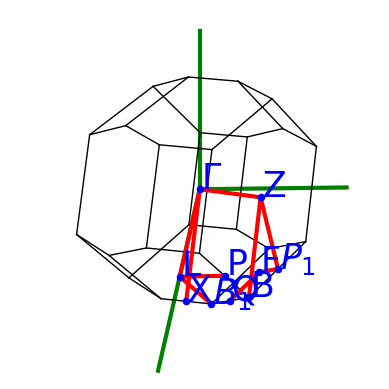

In [88]:
BSP = PhononBSPlotter(ph_bs)
BSP.plot_brillouin()

In [89]:
data = BSP.bs_plot_data()
distances = data['distances']
frequency = data['frequency']
directions = data['ticks']['label']
def find_acoustic_branches(frequencies):
    branche = []
    zone = []
    frequence = []
    for i in range(len(frequencies)):
        for j in range(len(frequencies[i])):
            # Vérifie si la fréquence est nulle au début ou à la fin (branche acoustique)
            if (frequencies[i][j][0] == 0 or frequencies[i][j][-1] == 0) and j not in branche and i not in zone:
                zone.append(i)
                branche.append(j)
                frequence.append(frequencies[i][j])
            if len(branche) == 3:  
                break
        if len(branche) == 3:
            break
    return frequence, branche, zone
frequence, branche, zone = find_acoustic_branches(frequency)
print("Branches acoustiques :", branche)
for i in zone:
    start_index = i
    end_index = i + 1
    if end_index < len(directions):
        print(f"Zone {i} : De {directions[start_index]} à {directions[end_index]}")
    else:
        print(f"Zone {i} : Fin de la zone de Brillouin")
q1 = distances[zone[0]]
q2 = distances[zone[1]]
q3 = distances[zone[2]]
f1 = frequency[zone[0]][branche[0]]
f2 = frequency[zone[1]][branche[1]]
f3 = frequency[zone[2]][branche[2]]

Branches acoustiques : [0, 1, 2]
Zone 0 : De $\Gamma$ à L
Zone 3 : De $B_1$|B à Z
Zone 4 : De Z à Z


In [90]:
def slope(q, f):
    coef = np.polyfit(q, f, 1)  
    absc = np.linspace(q[0], q[-1], 100) 
    tan = coef[0] * absc + coef[1]
    return (coef, absc, tan)
slope1 = slope(q1, f1)
slope2 = slope(q2, f2)
slope3 = slope(q3, f3)
v1 = abs(2 * math.pi * slope1[0][0] * 100)
v2 = abs(2 * math.pi * slope2[0][0] * 100)
v3 = abs(2 * math.pi * slope3[0][0] * 100)
print(v1)
print(v2)
print(v3)

2015.360358154774
76.58672502570805
2494.751354138682


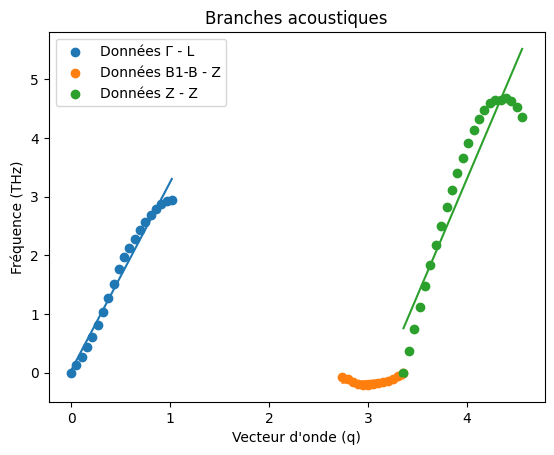

In [91]:
plt.scatter(q1, f1, label="Données Γ - L")
plt.plot(slope1[1], slope1[2])
plt.scatter(q2, f2, label="Données B1-B - Z")
plt.plot(slope2[1], slope2[2])
plt.scatter(q3, f3, label="Données Z - Z")
plt.plot(slope3[1], slope3[2])
plt.xlabel("Vecteur d'onde (q)")
plt.ylabel("Fréquence (THz)")
plt.legend()
plt.title("Branches acoustiques")
plt.show()